In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data_dir = '/Users/arpitkapoor/Library/CloudStorage/OneDrive-UNSW/Shared/Data/FEFLOW/'
patch_data_dir = os.path.join(data_dir, 'processed', 'patch_all_ts')
sea_level_csv_path = os.path.join(data_dir, 'simulation_files', 'SeaLevelDataPeaksHL.csv')

# load timesteps from sea level data
sea_level_data = pd.read_csv(sea_level_csv_path, names=['Time', 'SeaLevel'])
timesteps = sea_level_data['Time'].values

In [3]:
core_mass_conc_obs_list = []
core_hydraulic_head_obs_list = []
core_coords_list = []
for patch_dir in os.listdir(patch_data_dir):
    patch_path = os.path.join(patch_data_dir, patch_dir)
    if os.path.isdir(patch_path):
        patch_mass_conc_obs = np.load(os.path.join(patch_path, 'core_obs.npy'))[:,:,0].T
        patch_hydraulic_head_obs = np.load(os.path.join(patch_path, 'core_obs.npy'))[:,:,1].T
        patch_coords = np.load(os.path.join(patch_path, 'core_coords.npy'))
        core_mass_conc_obs_list.append(patch_mass_conc_obs)
        core_hydraulic_head_obs_list.append(patch_hydraulic_head_obs)
        core_coords_list.append(patch_coords)
        print(f"Patch: {patch_dir}, Core Observations Shape: {patch_mass_conc_obs.shape}, Core Coordinates Shape: {patch_coords.shape}")

core_mass_conc_obs = np.concatenate(core_mass_conc_obs_list, axis=0)
core_hydraulic_head_obs = np.concatenate(core_hydraulic_head_obs_list, axis=0)
core_coords = np.concatenate(core_coords_list, axis=0)
print(f"Combined Core Observations Shape: {core_mass_conc_obs.shape}, Combined Core Coordinates Shape: {core_coords.shape}")

Patch: patch_013, Core Observations Shape: (3647, 1909), Core Coordinates Shape: (3647, 3)
Patch: patch_014, Core Observations Shape: (3030, 1909), Core Coordinates Shape: (3030, 3)
Patch: patch_015, Core Observations Shape: (2727, 1909), Core Coordinates Shape: (2727, 3)
Patch: patch_012, Core Observations Shape: (2013, 1909), Core Coordinates Shape: (2013, 3)
Patch: patch_001, Core Observations Shape: (2117, 1909), Core Coordinates Shape: (2117, 3)
Patch: patch_006, Core Observations Shape: (3263, 1909), Core Coordinates Shape: (3263, 3)
Patch: patch_008, Core Observations Shape: (3594, 1909), Core Coordinates Shape: (3594, 3)
Patch: patch_009, Core Observations Shape: (1042, 1909), Core Coordinates Shape: (1042, 3)
Patch: patch_007, Core Observations Shape: (4516, 1909), Core Coordinates Shape: (4516, 3)
Patch: patch_019, Core Observations Shape: (3024, 1909), Core Coordinates Shape: (3024, 3)
Patch: patch_017, Core Observations Shape: (2022, 1909), Core Coordinates Shape: (2022, 3)

In [4]:
def normalize(arr):
    return (arr - np.mean(arr)) / np.std(arr)

def clip_outliers(arr):
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return np.clip(arr, lower_bound, upper_bound)

def remove_outliers(arr):
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return arr[(arr >= lower_bound) & (arr <= upper_bound)], (arr >= lower_bound) & (arr <= upper_bound)

In [5]:
delta_mass_conc = np.diff(normalize(core_mass_conc_obs), axis=1)
delta_time = np.diff(timesteps)
gradient_mass_conc = delta_mass_conc / delta_time
avg_gradient_mass_conc = np.mean(gradient_mass_conc, axis=1)

mask_mass = np.ones_like(avg_gradient_mass_conc, dtype=bool)  # Placeholder for outlier mask, replace with actual mask if needed
# avg_gradient_mass_conc = clip_outliers(avg_gradient_mass_c onc)
# avg_gradient_mass_conc, mask_mass = remove_outliers(avg_gradient_mass_conc)


delta_hydraulic_head = np.diff(normalize(core_hydraulic_head_obs), axis=1)
gradient_hydraulic_head = delta_hydraulic_head / delta_time
avg_gradient_hydraulic_head = np.mean(gradient_hydraulic_head, axis=1)


mask_hydraulic = np.ones_like(avg_gradient_hydraulic_head, dtype=bool)  # Placeholder for outlier mask, replace with actual mask if needed
# avg_gradient_hydraulic_head = clip_outliers(avg_gradient_hydraulic_head)
# avg_gradient_hydraulic_head, mask_hydraulic = remove_outliers(avg_gradient_hydraulic_head)

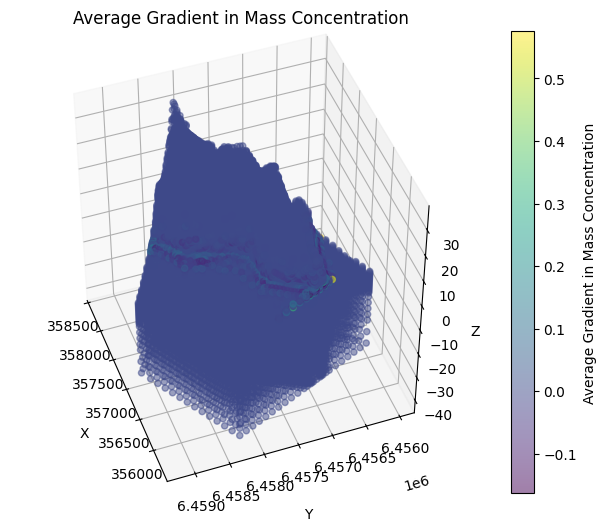

In [6]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(core_coords[mask_mass, 0], core_coords[mask_mass, 1], core_coords[mask_mass, 2], c=avg_gradient_mass_conc, cmap='viridis', alpha=0.5)
fig.colorbar(sc, label='Average Gradient in Mass Concentration')
ax.set_title('Average Gradient in Mass Concentration')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Aspect Ratio
ax.set_box_aspect((1, 1, 1.1))

# View Angle
ax.view_init(elev=45, azim=160)

# Padding
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 5

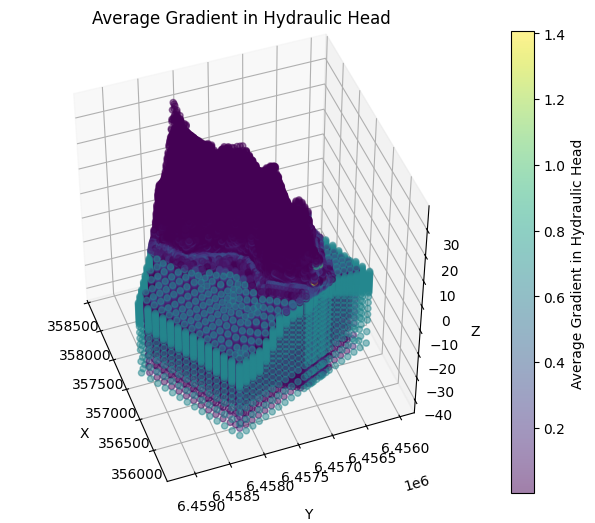

In [7]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(core_coords[mask_hydraulic, 0], core_coords[mask_hydraulic, 1], core_coords[mask_hydraulic, 2], c=np.abs(avg_gradient_hydraulic_head), cmap='viridis', alpha=0.5)
fig.colorbar(sc, label='Average Gradient in Hydraulic Head')
ax.set_title('Average Gradient in Hydraulic Head')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Aspect Ratio
ax.set_box_aspect((1, 1, 1.1))

# View Angle
ax.view_init(elev=45, azim=160)

# Padding
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.zaxis.labelpad = 5

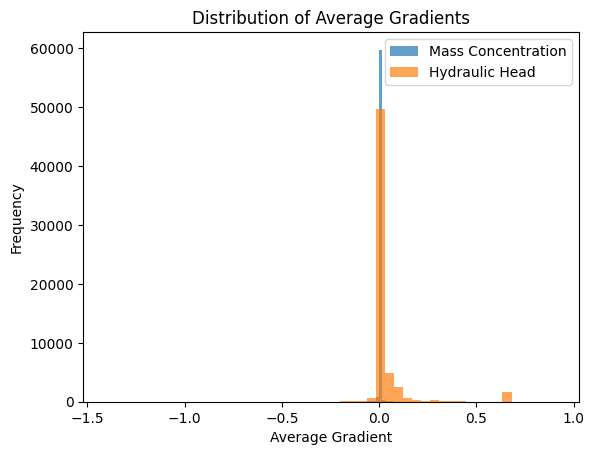

In [8]:
plt.hist(avg_gradient_mass_conc, bins=50, alpha=0.7, label='Mass Concentration')
plt.hist(avg_gradient_hydraulic_head, bins=50, alpha=0.7, label='Hydraulic Head')
plt.xlabel('Average Gradient')
plt.ylabel('Frequency')
plt.title('Distribution of Average Gradients')
plt.legend()
plt.show()

Autocorrelation

In [9]:
shifted_mass_conc = core_mass_conc_obs - core_mass_conc_obs.mean(axis=1, keepdims=True)
shifted_mass_conc.shape

(61360, 1909)